# 4. Scaled Dot-Product Attention с нуля

**Цель:** Реализовать механизм внимания с нуля на PyTorch, понять Query/Key/Value, визуализировать матрицу внимания и сравнить с оптимизированной реализацией.

---

## 🎭 Мем дня

*Attention: Query спрашивает, Key отвечает, Value передаёт. Классический love triangle из мира ML.*

![Мем про attention](memes/04_attention.png)


In [1]:
# === Настройка: импорты и конфигурация ===
import sys, os, logging, math
# Логирование для отслеживания форм тензоров на каждом шаге

# Torch для тензорных операций; nn.functional содержит softmax + оптимизированное внимание
import torch
import torch.nn as nn
import torch.nn.functional as F
# NumPy для энтропии и статистик распределения
import numpy as np
# Matplotlib для heatmap внимания и гистограмм scores
import matplotlib.pyplot as plt

# Вместо logging используем простой print — учебный курс, зачем нам логи?
import builtins as _builtins
def _log(msg, *args):
    if args:
        _builtins.print(msg % args)
    else:
        _builtins.print(msg)

import types
log = types.SimpleNamespace(info=_log, debug=_log, warning=_log, error=_log)



# Используем MPS (Apple Silicon Metal) вместо CPU для быстрого матричного умножения
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
log.info("Используем устройство: %s", device)


Используем устройство: mps


## 4.1 Постановка задачи: зачем нужно внимание?

**Проблема RNN/LSTM:**
- Скрытое состояние сжимает всю информацию о последовательности в один вектор
- При длинных последовательностях информация "забывается" (vanishing gradient)
- Нет прямого доступа к произвольным позициям входа

**Идея внимания (Bahdanau, 2014):**
- На каждом шаге декодирования "смотрим" на все позиции входа
- Решаем, какие части входа наиболее релевантны для текущего шага
- Взвешенная сумма скрытых состояний энкодера

**Scaled Dot-Product Attention (Vaswani et al., 2017):**
- Query (запрос) — что мы ищем
- Key (ключ) — что у нас есть
- Value (значение) — информация, которую мы хотим извлечь

## 4.2 Query, Key, Value — интуиция и математика

**Аналогия (поиск в словаре):**
- **Query** — слово, которое мы ищем
- **Key** — заголовки словарных статей
- **Value** — содержимое статей
- **Score** (Q·Kᵀ) — насколько хорошо запрос соответствует каждому ключу
- **Softmax** — нормализация scores в распределение вероятностей
- **Output** = взвешенная сумма Values по этим весам

**Математика:**
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Зачем делить на $\sqrt{d_k}$? Чтобы дисперсия scores оставалась ~1, и softmax не уходил в режим "почти one-hot" или "почти uniform" при большой размерности.

In [2]:
log.debug("Implementing scaled dot-product attention from scratch")

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled Dot-Product Attention.
    
    Args:
        Q: (batch, seq_len_q, d_k)
        K: (batch, seq_len_k, d_k)
        V: (batch, seq_len_k, d_v)
        mask: (batch, seq_len_q, seq_len_k) or (seq_len_q, seq_len_k) — True where masked
    
    Returns:
        output: (batch, seq_len_q, d_v)
        attention_weights: (batch, seq_len_q, seq_len_k)
    """
    d_k = Q.size(-1)
    # === 1. Dot-Product Scores: Q @ K^T (скалярные произведения) ===
    # Каждый элемент [i,j] = скалярное произведение Q[i] и K[j].
    # Большее значение = более сильное совпадение query-key в d_k-мерном пространстве.
    # Сложность: O(n²·d_k) — n² пар, каждая требует d_k умножений.
    scores = Q @ K.transpose(-2, -1)  # (batch, seq_len_q, seq_len_k)
    # === 2. Scaling: / sqrt(d_k) (масштабирование) ===
    # Почему: если Q,K ~ N(0,1), то Var(Q·K) = d_k. При d_k=512 дисперсия ~512.
    # Softmax on huge-variance inputs becomes near one-hot -> gradients vanish.
    # Деление на sqrt(d_k) нормализует дисперсию обратно к ~1: Var(·/sqrt(d_k)) = 1.
    scores = scores / math.sqrt(d_k)
    log.debug("Scores shape: %s, d_k=%d", scores.shape, d_k)
    # === 3. Masking (маскирование) ===
    # Заменяем padding-позиции (mask == 0) на -inf.
    # Why -inf: softmax(e^{-inf}) = 0 (zero weight); softmax(e^0) = 1 (distorts).
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
        log.debug("Mask applied, masked positions: %d", mask.eq(0).sum().item())
    # === 4. Softmax по ключам ===
    # p_j = exp(s_j) / sum_k exp(s_k) — каждая строка суммируется в 1.
    # Эти веса кодируют «сколько внимания» Q[i] уделяет K[j].
    attention_weights = F.softmax(scores, dim=-1)
    log.debug("Attention weights shape: %s", attention_weights.shape)
    # === 5. Weighted Sum: A @ V (взвешенная сумма) ===
    # output[i] = sum_j A[i,j] * V[j] — выпуклая комбинация Values.
    # Сложность: O(n²·d_v) — второй квадратичный член по n.
    output = attention_weights @ V  # (batch, seq_len_q, d_v)
    log.debug("Output shape: %s", output.shape)
    return output, attention_weights


Implementing scaled dot-product attention from scratch


## Почему Scaled Dot-Product: анализ дисперсии

Пусть $Q$ и $K$ — случайные векторы с независимыми компонентами, имеющими нулевое среднее и единичную дисперсию. Тогда каждый элемент матрицы $QK^T$ является суммой $d_k$ произведений:

$$(QK^T)_{ij} = \sum_{m=1}^{d_k} Q_{im} K_{jm}$$

Каждое слагаемое имеет среднее 0 и дисперсию 1, поэтому:

$$\mathbb{E}[(QK^T)_{ij}] = 0, \quad \mathbb{Var}[(QK^T)_{ij}] = d_k$$

**Проблема:** при больших $d_k$ дисперсия scores растёт линейно. Softmax от значений с большой дисперсией становится «острым» (peaky) — одно значение near 1, остальные near 0. Градиенты в таких регионах экспоненциально малы.

**Решение:** деление на $\sqrt{d_k}$ нормализует дисперсию обратно к 1:

$$\mathbb{Var}\left[\frac{(QK^T)_{ij}}{\sqrt{d_k}}\right] = 1$$

Теперь softmax получает входы с единичной дисперсией, градиенты остаются «здоровыми», и обучение стабильно.


Visualising score distribution before/after scaling


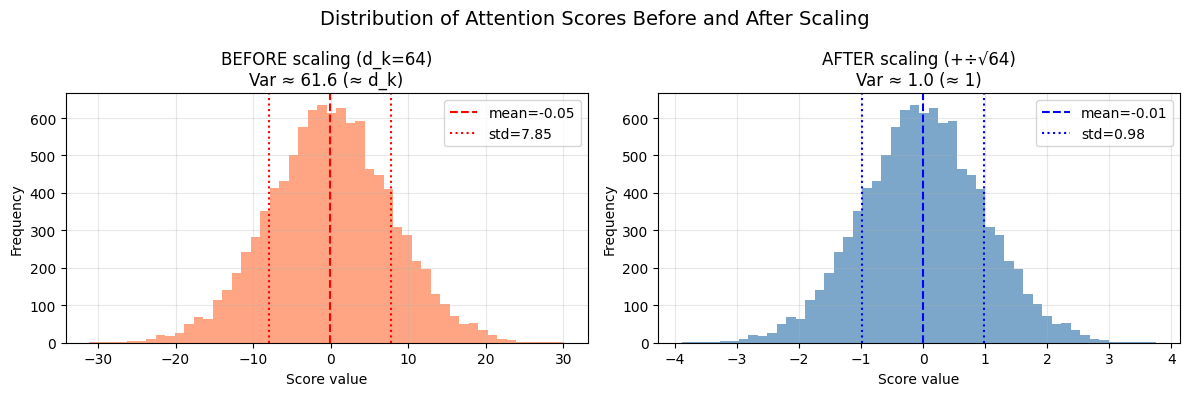

Score distribution visualisation complete


In [3]:
# === Визуализируем распределение scores ДО и ПОСЛЕ масштабирования ===
# Наглядно показывает, как sqrt(d_k) нормализует дисперсию с d_k обратно к 1
log.debug("Visualising score distribution before/after scaling")

d_k = 64
# Генерируем Q и K как в реальном attention: (1, N, d_k) -> scores (N, N)
seq_len = 100  # 100 токенов -> 10 000 пар scores
Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)

# Dot-product scores до и после масштабирования
scores = Q @ K.transpose(-2, -1)  # (1, 100, 100)
scores_before = scores.flatten()  # все 10 000 попарных значений
scores_after = scores_before / math.sqrt(d_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ДО масштабирования — широкий разброс, дисперсия ~ d_k
ax = axes[0]
ax.hist(scores_before.numpy(), bins=50, alpha=0.7, color="coral")
ax.axvline(scores_before.mean().item(), color="red", linestyle="--", label=f"mean={scores_before.mean():.2f}")
ax.axvline(scores_before.mean().item() + scores_before.std().item(), color="red", linestyle=":", label=f"std={scores_before.std():.2f}")
ax.axvline(scores_before.mean().item() - scores_before.std().item(), color="red", linestyle=":")
ax.set_title(f"BEFORE scaling (d_k={d_k})\nVar ≈ {scores_before.var():.1f} (≈ d_k)")
ax.set_xlabel("Score value")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, alpha=0.3)

# ПОСЛЕ масштабирования — узкий разброс, дисперсия ~ 1
ax = axes[1]
ax.hist(scores_after.numpy(), bins=50, alpha=0.7, color="steelblue")
ax.axvline(scores_after.mean().item(), color="blue", linestyle="--", label=f"mean={scores_after.mean():.2f}")
ax.axvline(scores_after.mean().item() + scores_after.std().item(), color="blue", linestyle=":", label=f"std={scores_after.std():.2f}")
ax.axvline(scores_after.mean().item() - scores_after.std().item(), color="blue", linestyle=":")
ax.set_title(f"AFTER scaling (+{chr(247)}{chr(8730)}{d_k})\nVar ≈ {scores_after.var():.1f} (≈ 1)")
ax.set_xlabel("Score value")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Distribution of Attention Scores Before and After Scaling", fontsize=14)
plt.tight_layout()
plt.show()
log.info("Score distribution visualisation complete")


In [4]:
log.debug("Testing attention on simple random data")

# 2 батча, 4 токена, размерность=8
batch_size, seq_len, d_k, d_v = 2, 4, 8, 8
# Случайные Q/K/V из N(0,1) — проверяем корректность размерностей
Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_v)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

# Проверяем размерности
print(f"Q shape:     {Q.shape}")
print(f"K shape:     {K.shape}")
print(f"V shape:     {V.shape}")
print(f"Output shape:{output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")

# Анализируем веса для первого элемента батча
print(f"\nAttention weights (batch 0):\n{attn_weights[0].detach().numpy().round(3)}")

# Ключевой инвариант: softmax гарантирует, что каждая строка суммируется в 1.0
print(f"\nRow sums (should be ~1.0): {attn_weights[0].sum(dim=-1).numpy().round(4)}")

log.info("Basic attention test passed")


Testing attention on simple random data
Scores shape: torch.Size([2, 4, 4]), d_k=8
Attention weights shape: torch.Size([2, 4, 4])
Output shape: torch.Size([2, 4, 8])
Q shape:     torch.Size([2, 4, 8])
K shape:     torch.Size([2, 4, 8])
V shape:     torch.Size([2, 4, 8])
Output shape:torch.Size([2, 4, 8])
Attention weights shape: torch.Size([2, 4, 4])

Attention weights (batch 0):
[[0.255 0.115 0.348 0.282]
 [0.232 0.17  0.373 0.224]
 [0.288 0.123 0.274 0.315]
 [0.126 0.566 0.183 0.125]]

Row sums (should be ~1.0): [1. 1. 1. 1.]
Basic attention test passed


## Вывод градиентов через attention

Рассмотрим проход внимания: $S = QK^T / \sqrt{d_k}$, $A = \text{softmax}(S)$, $O = AV$.

**Градиент по V:**
$$\frac{\partial L}{\partial V} = A^T \frac{\partial L}{\partial O}$$

**Градиент по A (весам внимания):**
$$\frac{\partial L}{\partial A} = \frac{\partial L}{\partial O} V^T$$

**Градиент по S (до softmax):**
$$\frac{\partial L}{\partial S} = A \odot \left( \frac{\partial L}{\partial A} - \mathbf{1} \left( A \odot \frac{\partial L}{\partial A} \right) \right)$$

где $\odot$ — поэлементное умножение, а $\mathbf{1}$ — матрица из единиц. Это локальная производная softmax: $dA/dS = A \cdot (\delta_{ij} - A_j)$.

**Градиент по Q и K:**
$$\frac{\partial L}{\partial Q} = \frac{1}{\sqrt{d_k}} \frac{\partial L}{\partial S} K, \quad
\frac{\partial L}{\partial K} = \frac{1}{\sqrt{d_k}} \frac{\partial L}{\partial S}^T Q$$

Весь градиентный поток выражается через матричные умножения — никаких рекуррентных зависимостей, что позволяет полностью распараллелить вычисления.


## 4.3 Визуализация матрицы внимания

Heatmap — основной инструмент анализа. Показывает, какие токены "смотрят" на какие.

Visualizing attention heatmap
Scores shape: torch.Size([1, 6, 6]), d_k=4
Attention weights shape: torch.Size([1, 6, 6])
Output shape: torch.Size([1, 6, 4])


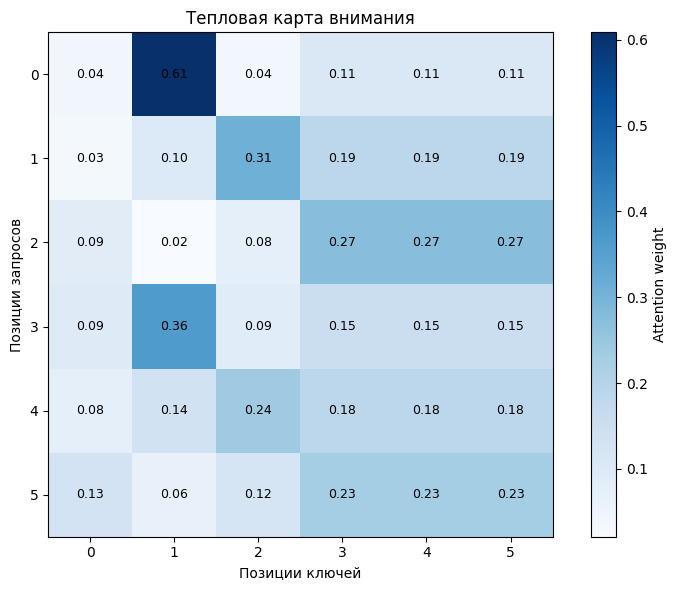

Attention heatmap plotted


In [5]:
log.debug("Visualizing attention heatmap")

# Синтетические данные с контролируемой структурой
seq_len = 6
d_k = 4

Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)
V = torch.randn(1, seq_len, d_k)

# Создаём паттерн: первые 3 запроса обращаются к последним 3 ключам
Q[:, :3, :] = 0
K[:, 3:, :] = 0
Q[:, :3, :] = Q[:, 3:, :] * 2  # усиливаем похожесть query-key

output, attn_weights = scaled_dot_product_attention(Q, K, V)

# Heatmap: строки=запросы, столбцы=ключи, цвет=вес внимания
plt.figure(figsize=(8, 6))
plt.imshow(attn_weights[0].detach().numpy(), cmap='Blues')
plt.colorbar(label='Attention weight')
plt.xlabel('Позиции ключей')
plt.ylabel('Позиции запросов')
plt.title('Тепловая карта внимания')
plt.xticks(range(seq_len))
plt.yticks(range(seq_len))
for i in range(seq_len):
    for j in range(seq_len):
        val = attn_weights[0, i, j].item()
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()
log.info("Attention heatmap plotted")


## 4.4 Маскировка: Padding Mask

В реальных данных последовательности имеют разную длину. Мы паддим (дополняем) короткие последовательности специальным PAD-токеном и маскируем его, чтобы он не влиял на attention.

Demonstrating padding mask
Padding mask:
tensor([[[ True,  True,  True, False, False]],

        [[ True,  True,  True,  True,  True]]])
Scores shape: torch.Size([2, 5, 5]), d_k=8
Mask applied, masked positions: 2
Attention weights shape: torch.Size([2, 5, 5])
Output shape: torch.Size([2, 5, 8])


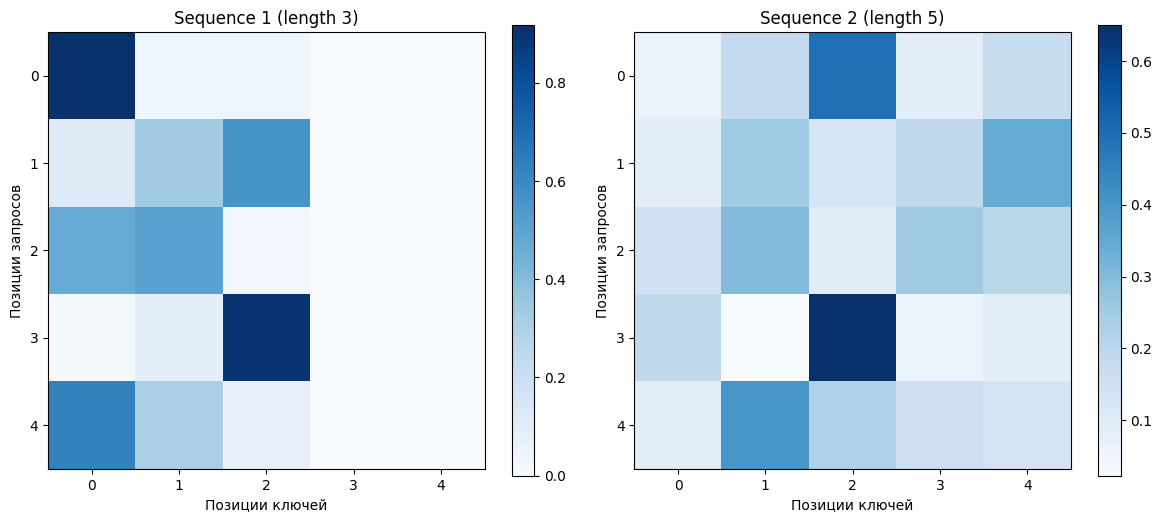

Padding mask visualization complete


In [6]:
log.debug("Demonstrating padding mask")

# 2 последовательности разной длины в одном батче
batch, seq_len, d_k = 2, 5, 8
lengths = torch.tensor([3, 5])

# === Строим маску ===
# mask[i,j] = True если j < lengths[i] (токен валидный, не padding)
# Broadcasting: torch.arange(5) -> (1,5); lengths.unsqueeze(1) -> (2,1)
# Результат: (2,5) — True для позиций до конца последовательности
mask = torch.arange(seq_len).unsqueeze(0) < lengths.unsqueeze(1)  # (batch, seq_len)
# Добавляем размерность головы для broadcasting с scores: (batch, 1, seq_len)
mask = mask.unsqueeze(1)  # (batch, 1, seq_len)
print(f"Padding mask:\n{mask}")

Q = torch.randn(batch, seq_len, d_k)
K = torch.randn(batch, seq_len, d_k)
V = torch.randn(batch, seq_len, d_k)

output, attn_weights = scaled_dot_product_attention(Q, K, V, mask=mask)

# Два heatmap: первая seq (длина 3) имеет позиции 3,4 замаскированными (нулевой вес)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i in range(2):
    ax = axes[i]
    im = ax.imshow(attn_weights[i].detach().numpy(), cmap='Blues')
    ax.set_title(f'Sequence {i+1} (length {lengths[i].item()})')
    ax.set_xlabel('Позиции ключей')
    ax.set_ylabel('Позиции запросов')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
log.info("Padding mask visualization complete")


## 4.5 Демонстрация на синтетических данных: поиск соответствий

Создадим задачу, где внимание естественно возникает: нужно найти, какие элементы одной последовательности соответствуют элементам другой.

Running attention demo on synthetic matching task
Scores shape: torch.Size([1, 6, 6]), d_k=16
Attention weights shape: torch.Size([1, 6, 6])
Output shape: torch.Size([1, 6, 16])


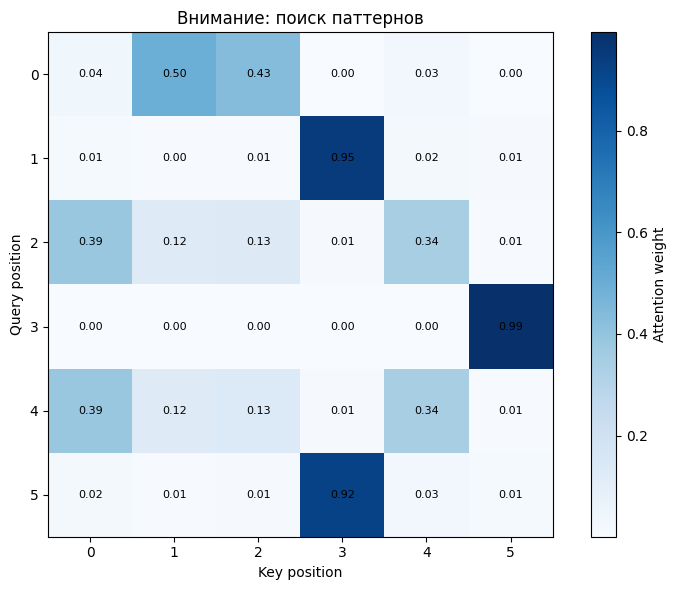

Pattern matching attention demo complete


In [7]:
log.debug("Running attention demo on synthetic matching task")

torch.manual_seed(42)
n_patterns = 4
d_k = 16
seq_len = 6

# Базовые паттерны с аддитивным шумом
patterns = torch.randn(n_patterns, d_k)

# Q и K взяты из тех же паттернов — attention должен находить соответствия
Q = patterns[torch.randint(0, n_patterns, (seq_len,))] + 0.1 * torch.randn(seq_len, d_k)
K = patterns[torch.randint(0, n_patterns, (seq_len,))] + 0.1 * torch.randn(seq_len, d_k)
V = K.clone()  # тождественное внимание: выход = взвешенные ключи

Q, K, V = Q.unsqueeze(0), K.unsqueeze(0), V.unsqueeze(0)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

# Ожидаем блочно-диагональную структуру (одинаковые паттерны соответствуют друг другу)
plt.figure(figsize=(8, 6))
plt.imshow(attn_weights[0].detach().numpy(), cmap='Blues')
plt.colorbar(label='Attention weight')
plt.title('Внимание: поиск паттернов')
plt.xlabel('Key position')
plt.ylabel('Query position')
for i in range(seq_len):
    for j in range(seq_len):
        val = attn_weights[0, i, j].item()
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()
log.info("Pattern matching attention demo complete")


## 4.6 Сравнение с оптимизированной реализацией PyTorch

PyTorch предоставляет `torch.nn.functional.scaled_dot_product_attention`. Сравним результаты.

In [8]:
log.debug("Comparing manual implementation with torch's optimized version")

torch.manual_seed(123)
batch, seq_len, d_k = 4, 8, 32
Q = torch.randn(batch, seq_len, d_k)
K = torch.randn(batch, seq_len, d_k)
V = torch.randn(batch, seq_len, d_k)

# Наша ручная реализация (Q@K, масштабирование, softmax, A@V)
output_manual, attn_manual = scaled_dot_product_attention(Q, K, V)

# Оптимизированная версия PyTorch: использует Flash Attention
# но математически эквивалентна нашей пошаговой версии
output_torch = F.scaled_dot_product_attention(Q, K, V)

# Должна совпадать в пределах точности float32
diff = (output_manual - output_torch).abs().max().item()
print(f"Max difference: {diff:.2e}")
print(f"Outputs match: {torch.allclose(output_manual, output_torch, atol=1e-6)}")
log.info("Comparison with F.scaled_dot_product_attention: max_diff=%.2e", diff)


Comparing manual implementation with torch's optimized version
Scores shape: torch.Size([4, 8, 8]), d_k=32
Attention weights shape: torch.Size([4, 8, 8])
Output shape: torch.Size([4, 8, 32])
Max difference: 3.58e-07
Outputs match: True
Comparison with F.scaled_dot_product_attention: max_diff=3.58e-07


In [9]:
# === Бенчмарк производительности ===
import time

log.debug("Running performance benchmark")

# Реалистичные размеры: большой батч, умеренная длина последовательности
batch, seq_len, d_k = 16, 128, 64
# Размещаем тензоры на целевом устройстве для реалистичного замера
Q = torch.randn(batch, seq_len, d_k, device=device)
K = torch.randn(batch, seq_len, d_k, device=device)
V = torch.randn(batch, seq_len, d_k, device=device)

def bench(fn, name, n_runs=20):
    # прогрев: заполнение кэша и JIT компиляция
    for _ in range(3):
        fn()
    if device.type == 'mps':
        torch.mps.synchronize()
    
    start = time.perf_counter()
    for _ in range(n_runs):
        fn()
    if device.type == 'mps':
        torch.mps.synchronize()
    elapsed = (time.perf_counter() - start) / n_runs
    print(f"{name:30s}: {elapsed*1000:.3f} ms")
    log.debug("Benchmark %s: %.3f ms", name, elapsed*1000)
    return elapsed

# Сравнение скорости ручной и оптимизированной версии PyTorch
manual_time = bench(lambda: scaled_dot_product_attention(Q, K, V), "Manual attention")
torch_time = bench(lambda: F.scaled_dot_product_attention(Q, K, V), "F.scaled_dot_product_attention")
print(f"Speedup: {manual_time / torch_time:.1f}x")


Running performance benchmark
Scores shape: torch.Size([16, 128, 128]), d_k=64
Attention weights shape: torch.Size([16, 128, 128])
Output shape: torch.Size([16, 128, 64])
Scores shape: torch.Size([16, 128, 128]), d_k=64
Attention weights shape: torch.Size([16, 128, 128])
Output shape: torch.Size([16, 128, 64])
Scores shape: torch.Size([16, 128, 128]), d_k=64
Attention weights shape: torch.Size([16, 128, 128])
Output shape: torch.Size([16, 128, 64])
Scores shape: torch.Size([16, 128, 128]), d_k=64
Attention weights shape: torch.Size([16, 128, 128])
Output shape: torch.Size([16, 128, 64])
Scores shape: torch.Size([16, 128, 128]), d_k=64
Attention weights shape: torch.Size([16, 128, 128])
Output shape: torch.Size([16, 128, 64])
Scores shape: torch.Size([16, 128, 128]), d_k=64
Attention weights shape: torch.Size([16, 128, 128])
Output shape: torch.Size([16, 128, 64])
Scores shape: torch.Size([16, 128, 128]), d_k=64
Attention weights shape: torch.Size([16, 128, 128])
Output shape: torch.Siz

## Сложность $O(n^2 \cdot d)$: откуда берётся квадрат

Основные операции Scaled Dot-Product Attention:

1. **Умножение Q и K^T:** $(n \times d) \cdot (d \times n) = O(n^2 \cdot d)$
   - Каждый из $n^2$ элементов матрицы внимания требует $d$ умножений
   - Это доминирующий член при $n \gg d$

2. **Softmax:** $O(n^2)$ — поэлементная операция, не доминирует

3. **Умножение A и V:** $(n \times n) \cdot (n \times d) = O(n^2 \cdot d)$
   - Второй квадратичный член

**Итог:** $O(n^2 \cdot d)$ — квадратичная сложность по длине последовательности.

**Почему это проблема:** при $n = 4096$ (типичный LLM) матрица внимания занимает $4096^2 \times 4$ байт $= 64$ МБ на голову. При 32 головах это уже 2 ГБ только на attention scores.

**Пути решения:**
- Sparse attention (только локальные паттерны)
- Linear attention (замена softmax на ядерный трюк)
- Flash Attention (аппаратно-оптимизированная реализация без материализации матрицы $n \times n$)


## 4.7 Визуализация: влияние масштабирования на softmax

Демонстрируем, почему деление на $\sqrt{d_k}$ критично.

Visualizing effect of scaling on softmax distribution


d_k=1: entropy unscaled=1.905, scaled=1.905


d_k=8: entropy unscaled=1.249, scaled=2.124
d_k=64: entropy unscaled=0.002, scaled=2.021
d_k=256: entropy unscaled=0.386, scaled=1.938


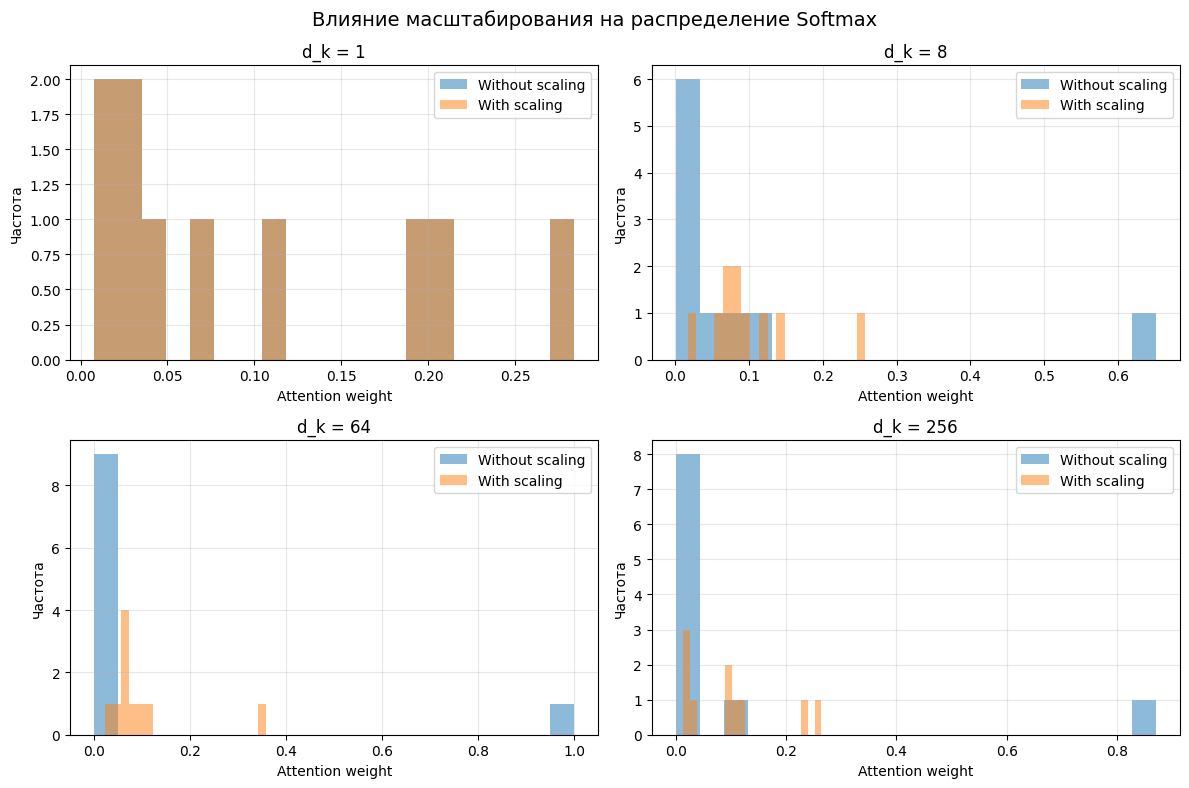

Scaling effect visualization complete


In [10]:
log.debug("Visualizing effect of scaling on softmax distribution")

# Для размерностей [1, 8, 64, 256] сравниваем softmax с масштабированием и без
dims = [1, 8, 64, 256]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, d_k in zip(axes.flat, dims):
    Q = torch.randn(1, 10, d_k)
    K = torch.randn(1, 10, d_k)
    
    scores = Q @ K.transpose(-2, -1)
    scores_scaled = scores / math.sqrt(d_k)
    
    probs = F.softmax(scores, dim=-1)[0, 0].detach().numpy()
    probs_scaled = F.softmax(scores_scaled, dim=-1)[0, 0].detach().numpy()
    
    # Без масштабирования: острый пик (один близок к 1, остальные к 0)
    # С масштабированием: более равномерное, лучший градиентный поток
    ax.hist(probs, bins=20, alpha=0.5, label='Without scaling')
    ax.hist(probs_scaled, bins=20, alpha=0.5, label='With scaling')
    ax.set_title(f'd_k = {d_k}')
    ax.set_xlabel('Attention weight')
    ax.set_ylabel('Частота')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    log.debug("d_k=%d: entropy unscaled=%.3f, scaled=%.3f",
              d_k,
              -((probs+1e-10)*np.log(probs+1e-10)).sum(),
              -((probs_scaled+1e-10)*np.log(probs_scaled+1e-10)).sum())

plt.suptitle('Влияние масштабирования на распределение Softmax', fontsize=14)
plt.tight_layout()
plt.show()
log.info("Scaling effect visualization complete")


In [11]:
# === Итог ===
print("=== Scaled Dot-Product Attention complete ===")
print("Topics covered:")
print("  - Scaled Dot-Product Attention from scratch")
print("  - Q, K, V intuition and mathematics")
print("  - Attention heatmap visualization")
print("  - Padding mask for variable-length sequences")
print("  - Pattern matching demo on synthetic data")
print("  - Comparison with F.scaled_dot_product_attention")
print("  - Performance benchmark")
print("  - Why scaling by sqrt(d_k) matters")
# Сложность: O(n²·d) — квадратичная по длине последовательности.
# Это главное узкое место для масштабирования контекста трансформеров.
log.info("Attention notebook complete")


=== Scaled Dot-Product Attention complete ===
Topics covered:
  - Scaled Dot-Product Attention from scratch
  - Q, K, V intuition and mathematics
  - Attention heatmap visualization
  - Padding mask for variable-length sequences
  - Pattern matching demo on synthetic data
  - Comparison with F.scaled_dot_product_attention
  - Performance benchmark
  - Why scaling by sqrt(d_k) matters
Attention notebook complete


📚 **Полезные ссылки:**
- [Attention Is All You Need (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762)
- [PyTorch: scaled_dot_product_attention](https://pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html)
